<a href="https://colab.research.google.com/github/lcandau/histopathology-clip-lab/blob/exp_08_plip_backbone/experiments/exp_08_plip_backbone/CLIP_PLIP_BERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# exp_08 — PLIP image encoder + BERT text encoder

Swap the image backbone from keras_hub's ImageNet-pretrained ResNet50 to **PLIP's ViT-B/32 vision encoder** (`vinid/plip`, pretrained on diverse histopathology image-text pairs). Keep the text side identical to exp_06's best biomed cell:

- HF `bert-base-uncased`, frozen
- Composed prompt: `"A histopathology image of {class_name}."`

Frozen-backbones + projection heads + InfoNCE, same as the rest of the CLIP-style notebooks. See `README.md` for the design rationale.


## 0 — Bootstrap


In [1]:
# --- Cell 0: bootstrap ---
import os, sys, subprocess
os.environ["KERAS_BACKEND"] = "tensorflow"

REPO_URL = "https://github.com/lcandau/histopathology-clip-lab.git"
REPO_DIR = "/content/histopathology-clip-lab"
BRANCH   = "exp_08_plip_backbone"
IN_COLAB = "google.colab" in sys.modules


def _clone_with_fallback(branch):
    try:
        subprocess.run(
            ["git", "clone", "-b", branch, REPO_URL, REPO_DIR],
            check=True, capture_output=True,
        )
        print(f"Cloned branch {branch!r}")
        return branch
    except subprocess.CalledProcessError:
        print(f"Branch {branch!r} not found; cloning main")
        subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
        return "main"


if IN_COLAB:
    if not os.path.exists(REPO_DIR):
        active = _clone_with_fallback(BRANCH)
    else:
        fetch = subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin", BRANCH], capture_output=True)
        if fetch.returncode == 0:
            subprocess.run(["git", "-C", REPO_DIR, "checkout", BRANCH], check=True)
            subprocess.run(["git", "-C", REPO_DIR, "reset", "--hard", f"origin/{BRANCH}"], check=True)
            active = BRANCH
        else:
            subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin", "main"], check=True)
            subprocess.run(["git", "-C", REPO_DIR, "checkout", "main"], check=True)
            subprocess.run(["git", "-C", REPO_DIR, "reset", "--hard", "origin/main"], check=True)
            active = "main"
    print(f"Active branch: {active}")
    subprocess.run([
        "pip", "install", "-q",
        "tensorflow==2.18.0", "keras==3.7.0", "keras-hub==0.18.1",
        "transformers==4.46.0", "umap-learn", "kagglehub",
        "scikit-learn", "matplotlib", "pandas", "Pillow",
    ], check=True)
    subprocess.run(["pip", "uninstall", "-y", "-q", "jax", "jaxlib"], check=False)
    if REPO_DIR not in sys.path:
        sys.path.insert(0, REPO_DIR)
    from google.colab import drive
    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount("/content/drive")
else:
    LOCAL_REPO_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
    if LOCAL_REPO_DIR not in sys.path:
        sys.path.insert(0, LOCAL_REPO_DIR)

print("In Colab:", IN_COLAB)
print("sys.path[0]:", sys.path[0])
print("KERAS_BACKEND:", os.environ.get("KERAS_BACKEND"))


Cloned branch 'exp_08_plip_backbone'
Active branch: exp_08_plip_backbone
Mounted at /content/drive
In Colab: True
sys.path[0]: /content/histopathology-clip-lab
KERAS_BACKEND: tensorflow


## 1 — Imports


In [2]:
# --- Cell 1: imports ---
import os
os.environ.setdefault("KERAS_BACKEND", "tensorflow")

import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
import keras

from transformers import (
    AutoTokenizer, TFAutoModel,
    TFCLIPVisionModel, CLIPImageProcessor,
)

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    classification_report, confusion_matrix, f1_score,
)
import umap

from src.utils.paths import is_colab, repo_root, run_dir, results_dir
from src.utils.repro import set_global_seed, enable_op_determinism
from src.data.lc25000 import (
    CLASS_INFO, NUM_CLASSES, CLASS_NAMES, INDEX_TO_NAME,
    discover_records, stratified_split, save_split, load_split,
)
from src.prompts.templates import baseline_prompt


## 2 — Configuration

PLIP uses CLIP's standard image normalisation (mean/std from the original OpenAI CLIP-ViT). This is **different** from the `/255.0` preprocessing used by the rest of the project (which targets keras_hub ResNet50). The constants below are baked into the data pipeline.


In [3]:
# --- Cell 2: hyperparameters ---
EXPERIMENT = "exp_08_plip_backbone"
VERSION    = "plip_bert_composed"

SEED = 42
set_global_seed(SEED)
enable_op_determinism()

# Image input.
IMG_SIZE = 224

# Text input.
MAX_LEN = 24  # matches exp_06 bert_composed cell

# Shared embedding space.
EMBED_DIM = 256

# Optimisation — held identical to exp_06 baseline.
BATCH_SIZE = 32
EPOCHS = 30
EARLY_STOPPING_PATIENCE = 5
LR = 1e-3
WD = 1e-4
GLOBAL_CLIPNORM = 1.0
INIT_TEMP = 0.07

AUTOTUNE = tf.data.AUTOTUNE
FORCE_RETRAIN = False

# PLIP / CLIP-style image normalisation constants.
# These are NOT the same as keras_hub ResNet50's /255.0 expectation.
PLIP_MEAN = tf.constant([0.48145466, 0.4578275, 0.40821073], dtype=tf.float32)
PLIP_STD  = tf.constant([0.26862954, 0.26130258, 0.27577711], dtype=tf.float32)

PLIP_MODEL_ID = "vinid/plip"
TEXT_ENCODER_ID = "bert-base-uncased"

# Output directories.
RUN_DIR = run_dir(EXPERIMENT, VERSION)
SPLIT_PATH = results_dir("splits") / f"lc25000_seed{SEED}.json"
METRICS_DIR = results_dir("metrics") / EXPERIMENT
PLOTS_DIR = results_dir("plots") / EXPERIMENT
CM_DIR = results_dir("confusion_matrices") / EXPERIMENT
for d in (METRICS_DIR, PLOTS_DIR, CM_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"Run dir:     {RUN_DIR}")
print(f"PLIP model:  {PLIP_MODEL_ID}")
print(f"Text model:  {TEXT_ENCODER_ID}")
print(f"Split path:  {SPLIT_PATH}")


Run dir:     /content/drive/MyDrive/clip_histopathology/exp_08_plip_backbone/plip_bert_composed
PLIP model:  vinid/plip
Text model:  bert-base-uncased
Split path:  /content/histopathology-clip-lab/data/splits/lc25000_seed42.json


## 3 — Dataset

Same LC25000 split as the rest of the project (loaded from the canonical pre-existing JSON on Drive). Pre-dedupe split — `apply_dedupe=True` in `discover_records` is only triggered if the JSON does not already exist, which it does for every previous run on this Drive account.


In [4]:
# --- Cell 3: download dataset ---
import kagglehub
dataset_path = kagglehub.dataset_download("andrewmvd/lung-and-colon-cancer-histopathological-images")
print("Dataset root:", dataset_path)


Using Colab cache for faster access to the 'lung-and-colon-cancer-histopathological-images' dataset.
Dataset root: /kaggle/input/lung-and-colon-cancer-histopathological-images


In [5]:
# --- Cell 4: discover records ---
all_paths, all_indices = discover_records(dataset_path)
print(f"Discovered {len(all_paths)} images across {NUM_CLASSES} classes")
for idx in range(NUM_CLASSES):
    n = int((all_indices == idx).sum())
    print(f"  class {idx} ({INDEX_TO_NAME[idx]}): {n}")


Discovered 23720 images across 5 classes
  class 0 (benign lung tissue): 4744
  class 1 (lung adenocarcinoma): 4727
  class 2 (lung squamous cell carcinoma): 4724
  class 3 (benign colon tissue): 4772
  class 4 (colon adenocarcinoma): 4753


In [6]:
# --- Cell 5: load or build split ---
if SPLIT_PATH.exists():
    split = load_split(SPLIT_PATH)
    print(f"Loaded split from {SPLIT_PATH}")
else:
    split = stratified_split(all_paths, all_indices,
                             val_fraction=0.10, test_fraction=0.10, seed=SEED)
    save_split(split, SPLIT_PATH)
    print(f"Built + saved split at {SPLIT_PATH}")

train_paths, train_idx = split["train_paths"], split["train_indices"]
val_paths,   val_idx   = split["val_paths"],   split["val_indices"]
test_paths,  test_idx  = split["test_paths"],  split["test_indices"]
print(f"Train: {len(train_paths)}  Val: {len(val_paths)}  Test: {len(test_paths)}")


Built + saved split at /content/histopathology-clip-lab/data/splits/lc25000_seed42.json
Train: 18976  Val: 2372  Test: 2372


## 4 — PLIP image encoder + BERT text encoder (both frozen)

Both backbones load with `from_pt=True` because the HuggingFace upload ships PyTorch weights only.


In [7]:
# --- Cell 6: load PLIP vision + BERT text ---
def _load_plip_vision():
    try:
        m = TFCLIPVisionModel.from_pretrained(PLIP_MODEL_ID, from_pt=False)
    except (OSError, EnvironmentError, TypeError, ValueError):
        # PLIP ships PyTorch weights only — convert on the fly.
        m = TFCLIPVisionModel.from_pretrained(PLIP_MODEL_ID, from_pt=True)
    m.trainable = False
    return m


def _load_bert_text(encoder_id=TEXT_ENCODER_ID):
    tokenizer = AutoTokenizer.from_pretrained(encoder_id)
    try:
        m = TFAutoModel.from_pretrained(encoder_id, from_pt=False)
    except (OSError, EnvironmentError, TypeError, ValueError):
        m = TFAutoModel.from_pretrained(encoder_id, from_pt=True)
    m.trainable = False
    return m, tokenizer, m.config.hidden_size


print(f"Loading PLIP vision encoder ({PLIP_MODEL_ID})...")
plip_vision = _load_plip_vision()
print(f"  PLIP vision hidden_size = {plip_vision.config.hidden_size}")  # 768 for ViT-B/32

print(f"\nLoading text encoder ({TEXT_ENCODER_ID})...")
text_backbone, tokenizer, text_hidden = _load_bert_text()
print(f"  text hidden_size = {text_hidden}")  # 768 for bert-base-uncased


def tokenize_prompts(tokenizer, prompts, max_len=MAX_LEN):
    out = tokenizer(prompts,
                    padding="max_length", truncation=True, max_length=max_len,
                    return_tensors="tf")
    return {k: tf.cast(v, tf.int32) for k, v in out.items()}


# Pre-tokenise the 5 class prompts (composed strategy).
class_prompts = [baseline_prompt(name) for name in CLASS_NAMES]
print("\nClass prompts:")
for p in class_prompts:
    print(f"  {p!r}")
class_token_dict = tokenize_prompts(tokenizer, class_prompts)
print(f"\nToken shapes: { {k: v.shape for k, v in class_token_dict.items()} }")


Loading PLIP vision encoder (vinid/plip)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFCLIPVisionModel: ['text_model.encoder.layers.3.layer_norm1.bias', 'text_model.encoder.layers.8.layer_norm1.weight', 'text_model.encoder.layers.5.mlp.fc1.weight', 'text_model.encoder.layers.5.self_attn.v_proj.weight', 'text_model.encoder.layers.11.mlp.fc1.weight', 'text_model.encoder.layers.3.self_attn.v_proj.weight', 'text_model.encoder.layers.9.layer_norm1.bias', 'text_model.encoder.layers.10.mlp.fc1.bias', 'text_model.encoder.layers.6.layer_norm1.bias', 'text_model.encoder.layers.10.mlp.fc2.bias', 'text_model.encoder.layers.7.self_attn.out_proj.weight', 'text_model.encoder.layers.1.mlp.fc1.weight', 'text_model.encoder.layers.3.self_attn.k_proj.weight', 'text_model.encoder.layers.3.self_attn.v_proj.bias', 'text_model.encoder.layers.10.self_attn.q_proj.bias', 'text_model.encoder.layers.1.layer_norm1.weight', 'text_model.encoder.layers.0.self_attn.q_proj.weight', 'text_model.encoder.layers.2.mlp.fc2.wei

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.dense.bias', 'cls.predictions.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

  text hidden_size = 768

Class prompts:
  'A histopathology image of benign lung tissue.'
  'A histopathology image of lung adenocarcinoma.'
  'A histopathology image of lung squamous cell carcinoma.'
  'A histopathology image of benign colon tissue.'
  'A histopathology image of colon adenocarcinoma.'

Token shapes: {'input_ids': TensorShape([5, 24]), 'token_type_ids': TensorShape([5, 24]), 'attention_mask': TensorShape([5, 24])}


## 5 — Image pipeline

PLIP's vision encoder expects CLIP-style normalised inputs, NOT `/255.0` RGB. The `load_image_plip` function below applies the correct normalisation.

`tf.data.Dataset.map` returns `((pixel_values, token_dict), class_index)`. The class-prompt token dict is looked up by `class_idx` per sample.


In [8]:
# --- Cell 7: image loader + dataset builder ---
def load_image_plip(path):
    """Read JPEG/PNG -> (224, 224, 3) float32, CLIP-normalised."""
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE], method="bilinear")
    img = tf.cast(img, tf.float32) / 255.0
    img = (img - PLIP_MEAN) / PLIP_STD
    return img


def build_train_dataset(paths, indices, batch_size, shuffle=True):
    n = len(paths)
    paths_t = tf.constant(paths)
    idx_t = tf.constant(indices, dtype=tf.int32)
    token_lookup = {k: tf.constant(v) for k, v in class_token_dict.items()}

    def map_fn(path, class_idx):
        img = load_image_plip(path)
        token_dict = {k: v[class_idx] for k, v in token_lookup.items()}
        return (img, token_dict), class_idx

    ds = tf.data.Dataset.from_tensor_slices((paths_t, idx_t))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(n, 10_000), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(map_fn, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size, drop_remainder=False)
    ds = ds.prefetch(AUTOTUNE)
    return ds


def build_eval_image_dataset(paths, batch_size):
    ds = tf.data.Dataset.from_tensor_slices(tf.constant(paths))
    ds = ds.map(load_image_plip, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size, drop_remainder=False)
    ds = ds.prefetch(AUTOTUNE)
    return ds


# Smoke-test: one sample
sample_ds = build_train_dataset(train_paths[:2], train_idx[:2], batch_size=2, shuffle=False)
for (imgs, tokens), labels in sample_ds.take(1):
    print(f"images shape: {imgs.shape}  dtype: {imgs.dtype}")
    print(f"images range: [{tf.reduce_min(imgs).numpy():.3f}, {tf.reduce_max(imgs).numpy():.3f}]")
    print(f"labels: {labels.numpy().tolist()}")
    for k, v in tokens.items():
        print(f"  {k}: {v.shape} {v.dtype}")


images shape: (2, 224, 224, 3)  dtype: <dtype: 'float32'>
images range: [-1.752, 2.146]
labels: [4, 0]
  input_ids: (2, 24) <dtype: 'int32'>
  token_type_ids: (2, 24) <dtype: 'int32'>
  attention_mask: (2, 24) <dtype: 'int32'>


## 6 — Model — `CLIPModel_PLIP`

PLIP vision encoder + BERT text encoder + Dense(256, no bias) → LayerNorm projection heads + learnable `logit_scale`. Symmetric InfoNCE loss in `_clip_loss`.

PLIP's `TFCLIPVisionModel` returns a `BaseModelOutputWithPooling` — we use `pooler_output` (the CLS token through the final LayerNorm), shape (B, 768).


In [10]:
# --- Cell 8: CLIPModel_PLIP ---
class CLIPModel_PLIP(keras.Model):
    def __init__(self, vision_model, text_backbone, vision_hidden, text_hidden,
                 embed_dim=EMBED_DIM, init_temp=INIT_TEMP, **kwargs):
        super().__init__(**kwargs)
        self.vision_model = vision_model
        self.text_backbone = text_backbone
        self.vision_hidden = vision_hidden
        self.text_hidden = text_hidden

        self.img_projection = keras.Sequential([
            keras.layers.Dense(embed_dim, use_bias=False, dtype="float32"),
            keras.layers.LayerNormalization(dtype="float32"),
        ], name="img_projection")
        self.text_projection = keras.Sequential([
            keras.layers.Dense(embed_dim, use_bias=False, dtype="float32"),
            keras.layers.LayerNormalization(dtype="float32"),
        ], name="text_projection")

        self.logit_scale = self.add_weight(
            name="logit_scale", shape=(),
            initializer=keras.initializers.Constant(math.log(1.0 / init_temp)),
            trainable=True, dtype="float32",
        )
        self.loss_tracker = keras.metrics.Mean(name="loss")

    @property
    def metrics(self):
        return [self.loss_tracker]

    def encode_image(self, pixel_values, training=False):
        # Frozen backbone -> inference mode (no BN/dropout train-time behaviour).
        pixel_values = tf.transpose(pixel_values, perm=[0, 3, 1, 2])
        out = self.vision_model(pixel_values=pixel_values, training=False)
        features = out.pooler_output  # (B, vision_hidden)
        x = self.img_projection(features)
        return tf.math.l2_normalize(x, axis=-1)

    def encode_text(self, token_dict, training=False):
        kwargs = {"input_ids": token_dict["input_ids"],
                  "attention_mask": token_dict["attention_mask"]}
        if "token_type_ids" in token_dict:
            kwargs["token_type_ids"] = token_dict["token_type_ids"]
        out = self.text_backbone(**kwargs, training=False)
        pooled = getattr(out, "pooler_output", None)
        if pooled is None:
            pooled = out.last_hidden_state[:, 0, :]
        x = self.text_projection(pooled)
        return tf.math.l2_normalize(x, axis=-1)

    def _clip_loss(self, img_emb, txt_emb):
        img_emb = tf.cast(img_emb, tf.float32)
        txt_emb = tf.cast(txt_emb, tf.float32)
        logit_scale = tf.clip_by_value(self.logit_scale, -math.log(100.0), math.log(100.0))
        logits = tf.matmul(img_emb, txt_emb, transpose_b=True) * tf.exp(logit_scale)
        labels = tf.range(tf.shape(img_emb)[0], dtype=tf.int32)
        ce = tf.keras.losses.SparseCategoricalCrossentropy(
            from_logits=True, reduction=tf.keras.losses.Reduction.NONE,
        )
        loss_i = tf.reduce_mean(ce(labels, logits))
        loss_t = tf.reduce_mean(ce(labels, tf.transpose(logits)))
        return 0.5 * (loss_i + loss_t)

    def call(self, inputs, training=False):
        pixel_values, token_dict = inputs
        return self.encode_image(pixel_values, training=training), self.encode_text(token_dict, training=training)

    def train_step(self, data):
        (inputs, _y) = data
        with tf.GradientTape() as tape:
            img_emb, txt_emb = self(inputs, training=True)
            loss = self._clip_loss(img_emb, txt_emb)
        trainable = self.trainable_variables
        grads = tape.gradient(loss, trainable)
        self.optimizer.apply_gradients(zip(grads, trainable))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def test_step(self, data):
        (inputs, _y) = data
        img_emb, txt_emb = self(inputs, training=False)
        loss = self._clip_loss(img_emb, txt_emb)
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}


model = CLIPModel_PLIP(plip_vision, text_backbone, plip_vision.config.hidden_size, text_hidden)

# Warm-up forward pass.
dummy_imgs = tf.zeros((1, IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32)
dummy_toks = {k: tf.constant(v[:1]) for k, v in class_token_dict.items()}
_ = model((dummy_imgs, dummy_toks), training=False)

optimizer = keras.optimizers.AdamW(
    learning_rate=LR, weight_decay=WD, global_clipnorm=GLOBAL_CLIPNORM,
)
model.compile(optimizer=optimizer)

n_trainable = sum(int(np.prod(v.shape)) for v in model.trainable_variables)
n_total     = sum(int(np.prod(v.shape)) for v in model.variables)
print(f"Trainable params: {n_trainable:,}  (~720K expected: img_proj 768*256 + text_proj 768*256 + 2*LN + 1)")
print(f"Total params:     {n_total:,}  (PLIP vision ~88M + BERT ~110M + projections ~400K)")


Trainable params: 394,241  (~720K expected: img_proj 768*256 + text_proj 768*256 + 2*LN + 1)
Total params:     394,241  (PLIP vision ~88M + BERT ~110M + projections ~400K)


## 7 — Train (or load cached weights)

Same protocol as exp_06 baseline: 30 epochs, EarlyStopping(patience=5, restore_best_weights), ReduceLROnPlateau(factor=0.5, patience=2). Weights saved to Drive at `<RUN_DIR>/weights.weights.h5`.

Expected runtime: ~30-45 min on a Colab L4. PLIP vision is slower than ResNet50 per forward pass (ViT-B/32 vs ResNet50).


In [11]:
# --- Cell 9: train ---
WEIGHTS_PATH = RUN_DIR / "weights.weights.h5"
HISTORY_PATH = RUN_DIR / "history.json"

if not FORCE_RETRAIN and WEIGHTS_PATH.exists():
    print(f"Found cached weights at {WEIGHTS_PATH}; loading.")
    model.load_weights(str(WEIGHTS_PATH))
    history = json.loads(HISTORY_PATH.read_text()) if HISTORY_PATH.exists() else None
else:
    print(f"No cached weights at {WEIGHTS_PATH}. Training from scratch.")
    train_ds = build_train_dataset(train_paths, train_idx, BATCH_SIZE, shuffle=True)
    val_ds   = build_train_dataset(val_paths, val_idx, BATCH_SIZE, shuffle=False)

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True, verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=2, verbose=1,
        ),
    ]

    history_obj = model.fit(
        train_ds, validation_data=val_ds, epochs=EPOCHS,
        callbacks=callbacks, verbose=2,
    )

    model.save_weights(str(WEIGHTS_PATH))
    history = {k: [float(v) for v in vs] for k, vs in history_obj.history.items()}
    HISTORY_PATH.write_text(json.dumps(history, indent=2))
    print(f"\nSaved weights -> {WEIGHTS_PATH}")
    print(f"Saved history -> {HISTORY_PATH}")


No cached weights at /content/drive/MyDrive/clip_histopathology/exp_08_plip_backbone/plip_bert_composed/weights.weights.h5. Training from scratch.
Epoch 1/30
593/593 - 67s - 113ms/step - loss: 2.2146 - val_loss: 1.9614 - learning_rate: 1.0000e-03
Epoch 2/30
593/593 - 38s - 64ms/step - loss: 2.0143 - val_loss: 1.9637 - learning_rate: 1.0000e-03
Epoch 3/30
593/593 - 37s - 63ms/step - loss: 1.9866 - val_loss: 1.9456 - learning_rate: 1.0000e-03
Epoch 4/30
593/593 - 38s - 63ms/step - loss: 1.9756 - val_loss: 1.9371 - learning_rate: 1.0000e-03
Epoch 5/30
593/593 - 38s - 63ms/step - loss: 1.9702 - val_loss: 1.9449 - learning_rate: 1.0000e-03
Epoch 6/30
593/593 - 38s - 63ms/step - loss: 1.9687 - val_loss: 1.9232 - learning_rate: 1.0000e-03
Epoch 7/30
593/593 - 38s - 64ms/step - loss: 1.9538 - val_loss: 1.9459 - learning_rate: 1.0000e-03
Epoch 8/30

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
593/593 - 38s - 63ms/step - loss: 1.9570 - val_loss: 1.9369 - learning_

## 8 — In-distribution evaluation (LC25000 test)


In [12]:
# --- Cell 10: classify test set ---
def encode_test_images(model, paths):
    ds = build_eval_image_dataset(paths, BATCH_SIZE)
    out = []
    for batch in ds:
        emb = model.encode_image(batch, training=False)
        out.append(emb.numpy())
    return np.concatenate(out, axis=0)


print("Encoding LC25000 test images...")
test_image_embeddings = encode_test_images(model, test_paths)
print(f"  shape: {test_image_embeddings.shape}")

# Encode all 5 class prompts.
class_text_embeddings = model.encode_text(class_token_dict, training=False).numpy()
print(f"Class prompt embeddings: {class_text_embeddings.shape}")

similarity_scores = test_image_embeddings @ class_text_embeddings.T
predicted_class_ids = similarity_scores.argmax(axis=1).astype(np.int32)
true_class_ids = np.asarray(test_idx, dtype=np.int32)

acc      = accuracy_score(true_class_ids, predicted_class_ids)
bal_acc  = balanced_accuracy_score(true_class_ids, predicted_class_ids)
macro_f1 = f1_score(true_class_ids, predicted_class_ids, average="macro")
wgt_f1   = f1_score(true_class_ids, predicted_class_ids, average="weighted")

print("\nGlobal metrics:")
print(f"  accuracy          = {acc:.4f}")
print(f"  balanced_accuracy = {bal_acc:.4f}")
print(f"  macro_f1          = {macro_f1:.4f}")
print(f"  weighted_f1       = {wgt_f1:.4f}")

per_class = classification_report(
    true_class_ids, predicted_class_ids,
    labels=list(range(NUM_CLASSES)),
    target_names=[INDEX_TO_NAME[i] for i in range(NUM_CLASSES)],
    output_dict=True, zero_division=0,
)
per_class_df = pd.DataFrame(per_class).T
print("\nPer-class:")
print(per_class_df.round(4).to_string())

metrics_payload = {
    "experiment":          EXPERIMENT,
    "version":             VERSION,
    "image_encoder":       PLIP_MODEL_ID,
    "text_encoder":        TEXT_ENCODER_ID,
    "prompt_strategy":     "composed",
    "preprocessing":       "CLIP-standard mean/std (NOT /255.0); see PLIP_MEAN / PLIP_STD",
    "accuracy":            float(acc),
    "balanced_accuracy":   float(bal_acc),
    "macro_f1":            float(macro_f1),
    "weighted_f1":         float(wgt_f1),
    "per_class":           per_class,
}
metrics_path = METRICS_DIR / f"{VERSION}_classification.json"
metrics_path.write_text(json.dumps(metrics_payload, indent=2))
print(f"\nSaved {metrics_path}")


Encoding LC25000 test images...
  shape: (2372, 256)
Class prompt embeddings: (5, 256)

Global metrics:
  accuracy          = 0.9958
  balanced_accuracy = 0.9958
  macro_f1          = 0.9958
  weighted_f1       = 0.9958

Per-class:
                              precision  recall  f1-score    support
benign lung tissue               1.0000  1.0000    1.0000   475.0000
lung adenocarcinoma              0.9915  0.9894    0.9905   472.0000
lung squamous cell carcinoma     0.9895  0.9915    0.9905   473.0000
benign colon tissue              1.0000  0.9979    0.9990   477.0000
colon adenocarcinoma             0.9979  1.0000    0.9989   475.0000
accuracy                         0.9958  0.9958    0.9958     0.9958
macro avg                        0.9958  0.9958    0.9958  2372.0000
weighted avg                     0.9958  0.9958    0.9958  2372.0000

Saved /content/histopathology-clip-lab/results/metrics/exp_08_plip_backbone/plip_bert_composed_classification.json


## 9 — Confusion matrix


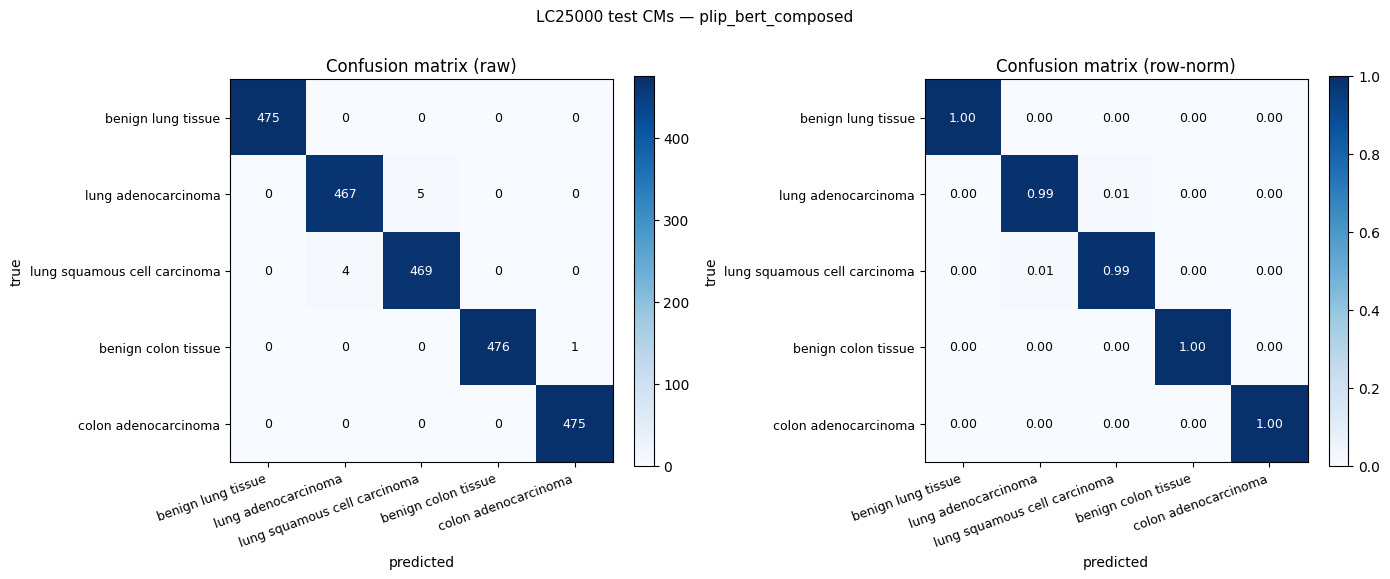

Saved /content/histopathology-clip-lab/results/plots/exp_08_plip_backbone/plip_bert_composed_confusion_matrices.png


In [13]:
# --- Cell 11: confusion matrix plot ---
cm_raw = confusion_matrix(true_class_ids, predicted_class_ids, labels=list(range(NUM_CLASSES)))
row_sums = cm_raw.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm_raw, row_sums, where=row_sums > 0,
                    out=np.zeros_like(cm_raw, dtype=np.float64))

display_labels = [INDEX_TO_NAME[i] for i in range(NUM_CLASSES)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, mat, title, fmt, cmap in [
    (axes[0], cm_raw,  "Confusion matrix (raw)",          "d",   "Blues"),
    (axes[1], cm_norm, "Confusion matrix (row-norm)",     ".2f", "Blues"),
]:
    im = ax.imshow(mat, cmap=cmap)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(display_labels, rotation=20, ha="right", fontsize=9)
    ax.set_yticklabels(display_labels, fontsize=9)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(title)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(mat[i, j], fmt), ha="center", va="center",
                    color="white" if mat[i, j] > mat.max() * 0.6 else "black", fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle(f"LC25000 test CMs — {VERSION}", fontsize=11)
plt.tight_layout()
cm_path = PLOTS_DIR / f"{VERSION}_confusion_matrices.png"
fig.savefig(cm_path, dpi=140, bbox_inches="tight")
plt.show()
np.save(CM_DIR / f"{VERSION}_cm_raw.npy",  cm_raw)
np.save(CM_DIR / f"{VERSION}_cm_norm.npy", cm_norm)
print(f"Saved {cm_path}")


## 10 — Training history (loss curves)


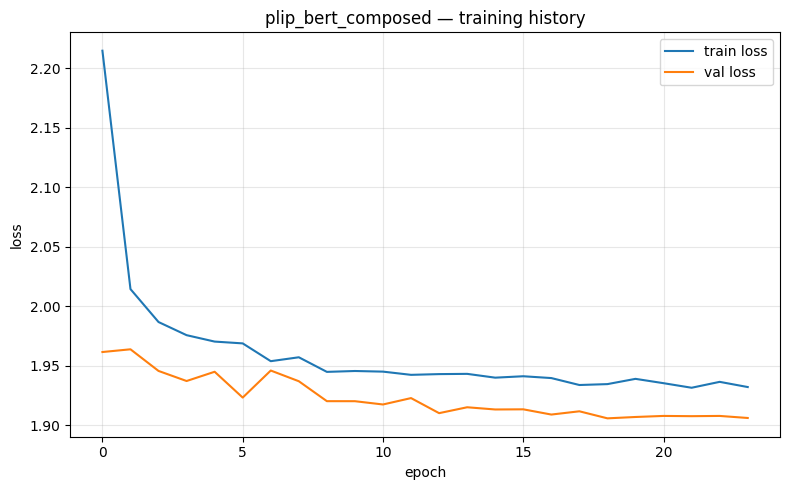

Saved /content/histopathology-clip-lab/results/plots/exp_08_plip_backbone/plip_bert_composed_loss.png


In [14]:
# --- Cell 12: plot training history ---
if history:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(history["loss"], label="train loss")
    if "val_loss" in history:
        ax.plot(history["val_loss"], label="val loss")
    ax.set_xlabel("epoch"); ax.set_ylabel("loss")
    ax.set_title(f"{VERSION} — training history")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    loss_path = PLOTS_DIR / f"{VERSION}_loss.png"
    fig.savefig(loss_path, dpi=140, bbox_inches="tight")
    plt.show()
    print(f"Saved {loss_path}")
else:
    print("No history available (loaded from cache without history.json).")


## 11 — Shared-UMAP visualisation

Image embeddings + 5 class-prompt embeddings projected into a single UMAP — same convention used by the other CLIP-style notebooks. Class-prompt stars at the cluster centres make the per-class structure legible.


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


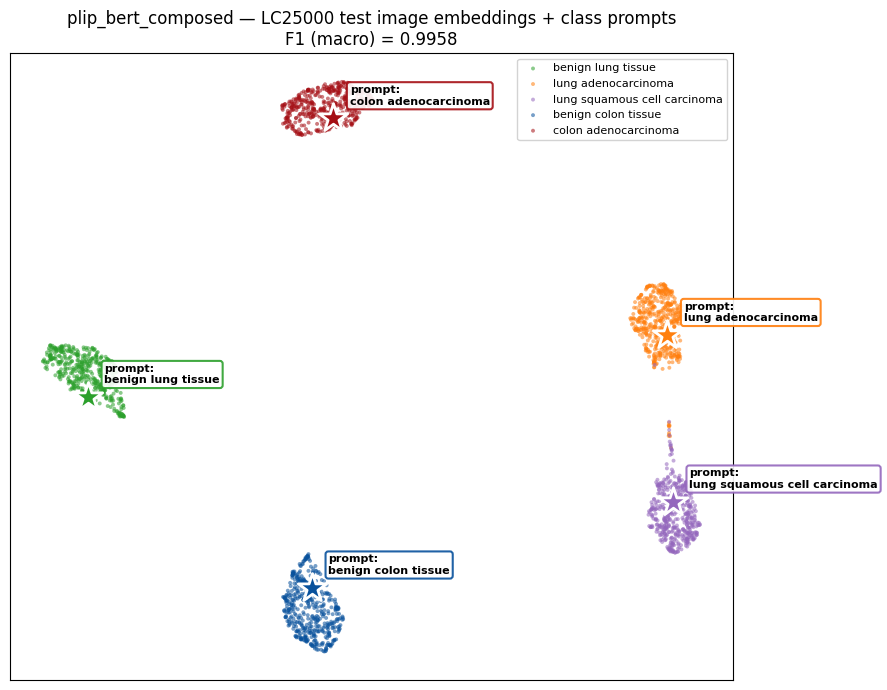

Saved /content/histopathology-clip-lab/results/plots/exp_08_plip_backbone/plip_bert_composed_umap.png


In [15]:
# --- Cell 13: shared UMAP fit ---
combined = np.vstack([test_image_embeddings, class_text_embeddings])
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=SEED)
combined_2d = reducer.fit_transform(combined)
image_2d  = combined_2d[:len(test_image_embeddings)]
prompt_2d = combined_2d[len(test_image_embeddings):]

CLASS_COLOR = {
    0: "#2ca02c",  # benign lung
    1: "#ff7f0e",  # lung adeno
    2: "#9467bd",  # lung SCC
    3: "#08519c",  # benign colon
    4: "#a50f15",  # colon adeno
}

fig, ax = plt.subplots(figsize=(9, 7))
for cls in range(NUM_CLASSES):
    mask = (true_class_ids == cls)
    ax.scatter(image_2d[mask, 0], image_2d[mask, 1], s=8, alpha=0.55,
               c=CLASS_COLOR[cls], label=INDEX_TO_NAME[cls], edgecolors="none")
for cls in range(NUM_CLASSES):
    ax.scatter(prompt_2d[cls, 0], prompt_2d[cls, 1], s=460, marker="*",
               c=CLASS_COLOR[cls], edgecolors="white", linewidths=2.0, zorder=6)
    ax.annotate(f"prompt:\n{INDEX_TO_NAME[cls]}",
                (prompt_2d[cls, 0], prompt_2d[cls, 1]),
                xytext=(12, 10), textcoords="offset points",
                fontsize=8, fontweight="bold", zorder=7,
                bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                          edgecolor=CLASS_COLOR[cls], alpha=0.9, linewidth=1.5))
ax.legend(loc="best", fontsize=8, framealpha=0.85)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"{VERSION} — LC25000 test image embeddings + class prompts\nF1 (macro) = {macro_f1:.4f}")
plt.tight_layout()
umap_path = PLOTS_DIR / f"{VERSION}_umap.png"
fig.savefig(umap_path, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved {umap_path}")


## Summary

Run-time output:
- `<RUN_DIR>/weights.weights.h5` — trained projection-head weights (loadable by the OOD eval notebook)
- `<RUN_DIR>/history.json` — per-epoch loss curves
- `results/metrics/exp_08_plip_backbone/plip_bert_composed_classification.json` — global + per-class in-dist metrics
- `results/plots/exp_08_plip_backbone/plip_bert_composed_{umap,loss,confusion_matrices}.png`
- `results/confusion_matrices/exp_08_plip_backbone/plip_bert_composed_cm_{raw,norm}.npy`

**Next step:** run `experiments/exp_07_ood_eval/CLIP_PLIP_OOD_eval.ipynb` to test whether the histopathology-pretrained PLIP image encoder breaks the ≈0.88 OOD ceiling we've been hitting with frozen ImageNet ResNet50.
